
# MOGA-Phonons correlation heat maps

This notebook aggregates `dataframe000013.pkl` and `dataframe000014.pkl`, computes Pearson and Spearman correlation matrices, and saves publication-quality heat maps.

The default variables emphasize the quantities most useful for interpreting the genetic search:

- BvK parameters: `alpha0`, `alpha1`, `beta1`, `alpha2`, `beta2`
- Lattice descriptors: mass and lattice parameter
- Fitness quantities: `fitness1`, `fitness2`, `fitness3`, `fitness_norm`
- Stability/phonon descriptors when available


In [1]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

# -----------------------------------------------------------------------------
# User settings
# -----------------------------------------------------------------------------

# Change this to the directory containing dataframe000013.pkl and dataframe000014.pkl.
# If the notebook is inside the MOGA-Phonons repository, this default should work.
DATAFRAME_DIR = Path("./dataframes")

DATAFRAME_FILES = {
    "dataframe000013": DATAFRAME_DIR / "dataframe000013.pkl",
    "dataframe000014": DATAFRAME_DIR / "dataframe000014.pkl",
    "dataframe000015": DATAFRAME_DIR / "dataframe000015.pkl",
    "dataframe000016": DATAFRAME_DIR / "dataframe000016.pkl",
    
}

OUTPUT_DIR = Path("correlation_heatmaps_013_014")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REQUESTED_COLUMNS = [
    "mass", "m", "a_val", "alat", "a_latt", "lattice_parameter",
    "alpha0", "alpha1", "beta1", "alpha2", "beta2",
    "fitness1", "fitness2", "fitness3", "fitness_norm",
    "min_frequency", "max_frequency", "num_imaginary_modes", "is_stable",
    "gamma_acoustic_0", "gamma_acoustic_1", "gamma_acoustic_2",
]

DISPLAY_NAMES = {
    "mass": r"$m$", "m": r"$m$",
    "a_val": r"$a$", "alat": r"$a$", "a_latt": r"$a$", "lattice_parameter": r"$a$",
    "alpha0": r"$\alpha_0$", "alpha1": r"$\alpha_1$", "beta1": r"$\beta_1$",
    "alpha2": r"$\alpha_2$", "beta2": r"$\beta_2$",
    "fitness1": r"$f_1$", "fitness2": r"$f_2$", "fitness3": r"$f_3$",
    "fitness_norm": r"$f_{\mathrm{norm}}$",
    "min_frequency": r"$\omega_{\min}$", "max_frequency": r"$\omega_{\max}$",
    "num_imaginary_modes": r"$N_-$", "is_stable": "Stable",
    "gamma_acoustic_0": r"$\Gamma_1$", "gamma_acoustic_1": r"$\Gamma_2$", "gamma_acoustic_2": r"$\Gamma_3$",
}

FIGSIZE = (9.0, 7.5)
DPI = 600
FONT_SIZE = 14
ANNOT_SIZE = 9


In [2]:

def load_dataframe(path, label):
    """Load a pickle dataframe and attach a source label."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. Update DATAFRAME_DIR or DATAFRAME_FILES above."
        )
    df = pd.read_pickle(path).copy()
    df["dataset"] = label
    return df

frames = []
for label, path in DATAFRAME_FILES.items():
    df_i = load_dataframe(path, label)
    print(f"Loaded {label}: {df_i.shape[0]:,} rows, {df_i.shape[1]:,} columns")
    frames.append(df_i)

df = pd.concat(frames, ignore_index=True)
print(f"\nAggregated dataframe: {df.shape[0]:,} rows, {df.shape[1]:,} columns")
print("\nColumns:")
print(list(df.columns))


Loaded dataframe000013: 105,000 rows, 35 columns
Loaded dataframe000014: 105,000 rows, 35 columns
Loaded dataframe000015: 105,000 rows, 35 columns
Loaded dataframe000016: 105,000 rows, 35 columns

Aggregated dataframe: 420,000 rows, 35 columns

Columns:
['simulation', 'generation', 'solution_index', 'rank', 'source', 'timestamp', 'mass', 'a_val', 'system_size', 'alpha0', 'alpha1', 'beta1', 'alpha2', 'beta2', 'fitness', 'fitness1', 'fitness2', 'fitness3', 'fitness_norm', 'sort_by', 'sort_score', 'min_frequency', 'max_frequency', 'num_imaginary', 'stable', 'gamma_frequencies', 'distances', 'qpoints', 'frequencies', 'frequency_vector', 'simulation_path', 'generation_dir', 'solution_dir', 'band_yaml_path', 'dataset']


In [3]:

def find_first_existing(possible_names, columns):
    """Return the first matching column name from possible_names."""
    for name in possible_names:
        if name in columns:
            return name
    return None

mass_col = find_first_existing(["mass", "m"], df.columns)
alat_col = find_first_existing(["a_val", "alat", "a_latt", "lattice_parameter"], df.columns)

print(f"Detected mass column: {mass_col}")
print(f"Detected lattice-parameter column: {alat_col}")

existing_requested = [c for c in REQUESTED_COLUMNS if c in df.columns]

if mass_col is not None:
    existing_requested = [c for c in existing_requested if c not in ["mass", "m"]]
    existing_requested.insert(0, mass_col)

if alat_col is not None:
    existing_requested = [c for c in existing_requested if c not in ["a_val", "alat", "a_latt", "lattice_parameter"]]
    existing_requested.insert(1 if mass_col is not None else 0, alat_col)

correlation_columns = []
for c in existing_requested:
    if pd.api.types.is_numeric_dtype(df[c]) or pd.api.types.is_bool_dtype(df[c]):
        correlation_columns.append(c)

print("\nColumns used for correlations:")
print(correlation_columns)

corr_df = df[correlation_columns].copy()

for c in corr_df.columns:
    if pd.api.types.is_bool_dtype(corr_df[c]):
        corr_df[c] = corr_df[c].astype(int)
    corr_df[c] = pd.to_numeric(corr_df[c], errors="coerce")

valid_columns = []
for c in corr_df.columns:
    series = corr_df[c].dropna()
    if len(series) > 1 and series.nunique() > 1:
        valid_columns.append(c)

corr_df = corr_df[valid_columns]

print("\nFinal non-constant numeric columns:")
print(list(corr_df.columns))
print(f"Rows available before pairwise correlation: {len(corr_df):,}")


Detected mass column: mass
Detected lattice-parameter column: a_val

Columns used for correlations:
['mass', 'a_val', 'alpha0', 'alpha1', 'beta1', 'alpha2', 'beta2', 'fitness1', 'fitness2', 'fitness3', 'fitness_norm', 'min_frequency', 'max_frequency']

Final non-constant numeric columns:
['mass', 'a_val', 'alpha0', 'alpha1', 'beta1', 'alpha2', 'beta2', 'fitness1', 'fitness2', 'fitness3', 'fitness_norm', 'min_frequency', 'max_frequency']
Rows available before pairwise correlation: 420,000


In [4]:

def pretty_labels(columns):
    """Return display labels for heat map axes."""
    return [DISPLAY_NAMES.get(c, c.replace("_", " ")) for c in columns]


def compute_correlations(data):
    """Compute Pearson and Spearman correlations."""
    pearson = data.corr(method="pearson")
    spearman = data.corr(method="spearman")
    return pearson, spearman

pearson_corr, spearman_corr = compute_correlations(corr_df)

pearson_corr.to_csv(OUTPUT_DIR / "pearson_correlation_matrix.csv")
spearman_corr.to_csv(OUTPUT_DIR / "spearman_correlation_matrix.csv")

pearson_corr


,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness1,fitness2,fitness3,fitness_norm,min_frequency,max_frequency
mass,1.000000e+00,1.999642e-14,0.014736,0.010271,0.002608,0.077264,-0.054167,-0.011451,0.025739,0.065449,0.068070,0.063880,-0.680410
a_val,1.999642e-14,1.000000e+00,-0.092658,-0.048814,-0.010544,-0.066950,0.136762,0.000398,-0.000039,0.003406,0.003907,0.025783,-0.075799
alpha0,1.473642e-02,-9.265820e-02,1.000000,-0.501809,-0.004605,0.105550,-0.275240,0.016686,0.003214,0.013330,0.017130,-0.016665,0.594498
alpha1,1.027122e-02,-4.881423e-02,-0.501809,1.000000,0.026162,0.096625,-0.598128,-0.012914,0.001466,-0.051679,-0.041927,0.002307,-0.200575
beta1,2.607869e-03,-1.054371e-02,-0.004605,0.026162,1.000000,0.043934,-0.040403,-0.001143,-0.011566,0.005786,0.001973,-0.129927,0.001911
alpha2,7.726381e-02,-6.695013e-02,0.105550,0.096625,0.043934,1.000000,-0.613464,0.020478,0.026652,0.060115,0.047144,0.095831,-0.091622
beta2,-5.416749e-02,1.367623e-01,-0.275240,-0.598128,-0.040403,-0.613464,1.000000,-0.009146,-0.012415,0.009928,0.005630,-0.022065,-0.180697
fitness1,-1.145120e-02,3.983786e-04,0.016686,-0.012914,-0.001143,0.020478,-0.009146,1.000000,0.002246,-0.003609,0.084545,0.022004,0.013087
fitness2,2.573911e-02,-3.937338e-05,0.003214,0.001466,-0.011566,0.026652,-0.012415,0.002246,1.000000,0.329333,0.647529,0.115064,-0.020201
fitness3,6.544928e-02,3.406007e-03,0.013330,-0.051679,0.005786,0.060115,0.009928,-0.003609,0.329333,1.000000,0.921774,0.088049,-0.053512


Saved correlation_heatmaps_013_014/pearson_correlation_heatmap.png
Saved correlation_heatmaps_013_014/pearson_correlation_heatmap.pdf


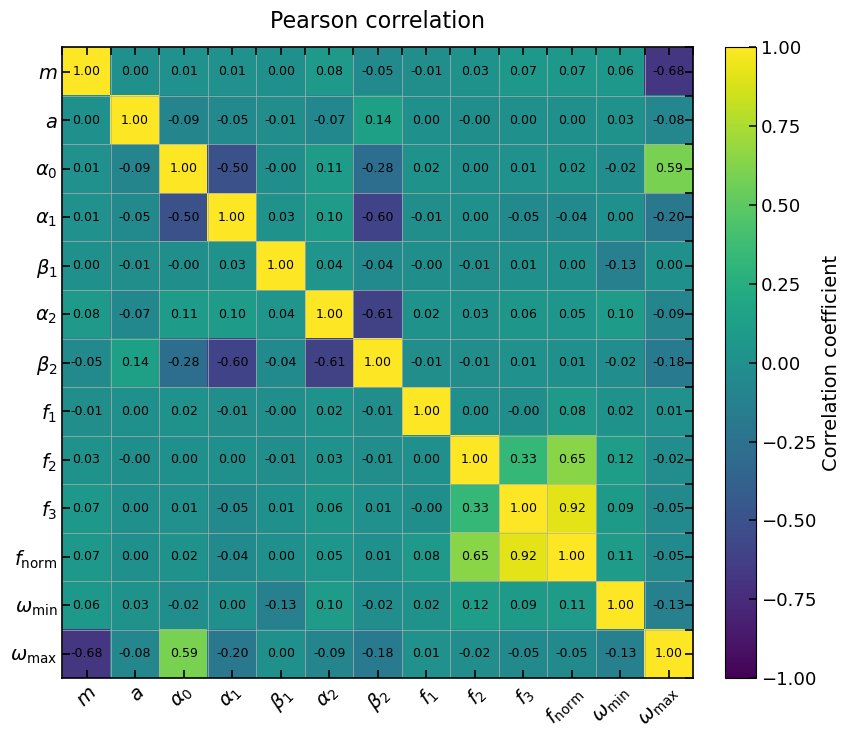

In [5]:

def plot_correlation_heatmap(corr, title, filename_stem, annotate=True, figsize=FIGSIZE, dpi=DPI):
    """Create and save a publication-quality correlation heat map."""
    labels = pretty_labels(corr.columns)
    n = len(labels)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr.values, vmin=-1, vmax=1, interpolation="nearest")

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor", fontsize=FONT_SIZE)
    ax.set_yticklabels(labels, fontsize=FONT_SIZE)

    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    ax.tick_params(axis="both", which="both", direction="in", top=True, right=True, length=6, width=1.2)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)

    if annotate:
        for i in range(n):
            for j in range(n):
                value = corr.values[i, j]
                if np.isfinite(value):
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=ANNOT_SIZE)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation coefficient", fontsize=FONT_SIZE)
    cbar.ax.tick_params(labelsize=FONT_SIZE - 1, direction="in", length=5, width=1.1)

    ax.set_title(title, fontsize=FONT_SIZE + 2, pad=14)
    fig.tight_layout()

    png_path = OUTPUT_DIR / f"{filename_stem}.png"
    pdf_path = OUTPUT_DIR / f"{filename_stem}.pdf"
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {png_path}")
    print(f"Saved {pdf_path}")
    return fig, ax

fig, ax = plot_correlation_heatmap(
    pearson_corr,
    title="Pearson correlation",
    filename_stem="pearson_correlation_heatmap",
    annotate=True,
)
plt.show()


Saved correlation_heatmaps_013_014/spearman_correlation_heatmap.png
Saved correlation_heatmaps_013_014/spearman_correlation_heatmap.pdf


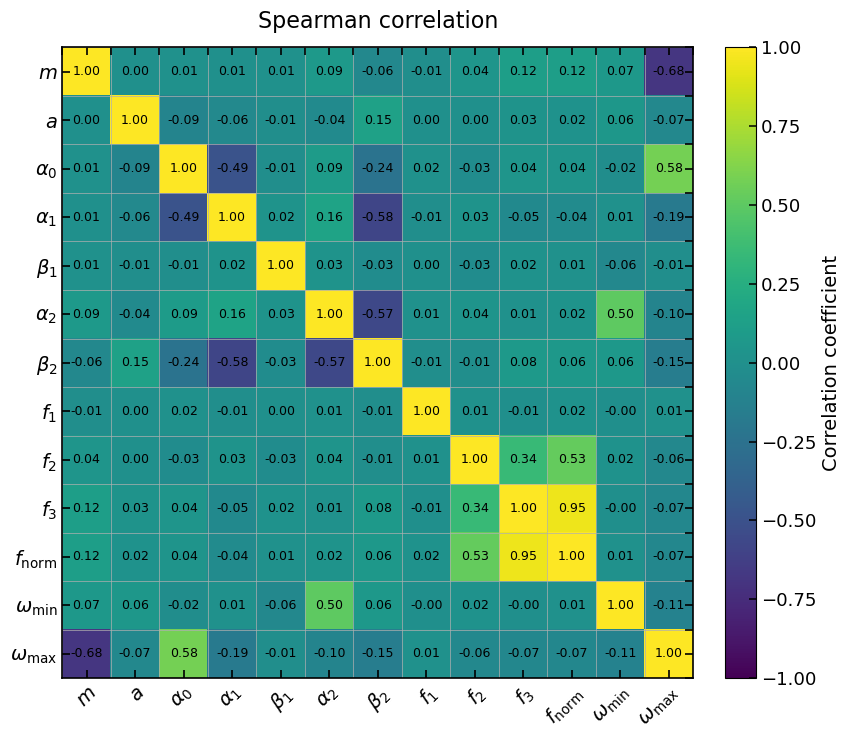

In [6]:

fig, ax = plot_correlation_heatmap(
    spearman_corr,
    title="Spearman correlation",
    filename_stem="spearman_correlation_heatmap",
    annotate=True,
)
plt.show()


Saved correlation_heatmaps_013_014/pearson_correlation_heatmap_no_annotations.png
Saved correlation_heatmaps_013_014/pearson_correlation_heatmap_no_annotations.pdf


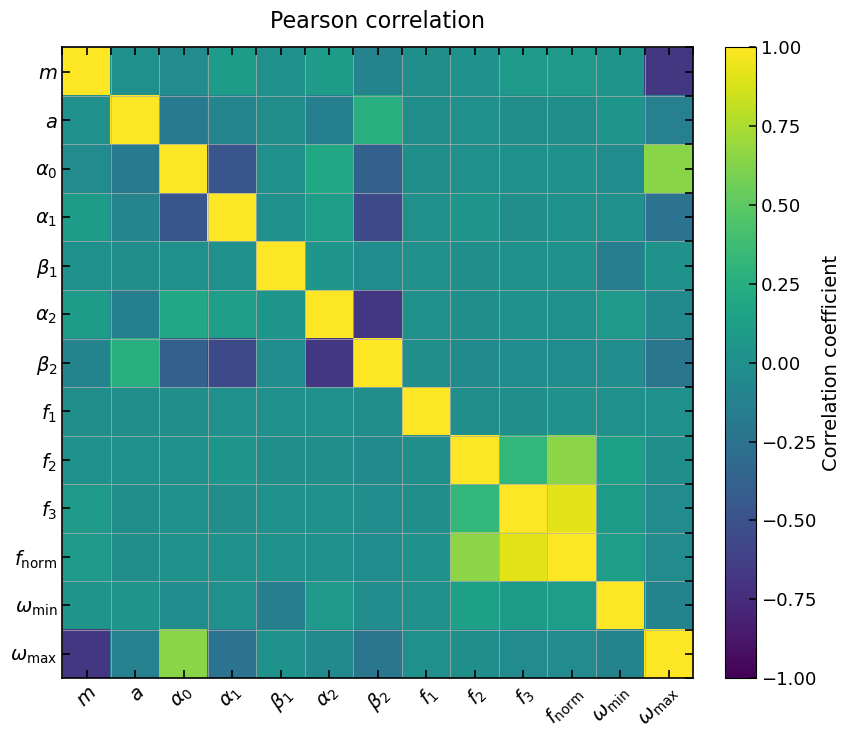

Saved correlation_heatmaps_013_014/spearman_correlation_heatmap_no_annotations.png
Saved correlation_heatmaps_013_014/spearman_correlation_heatmap_no_annotations.pdf


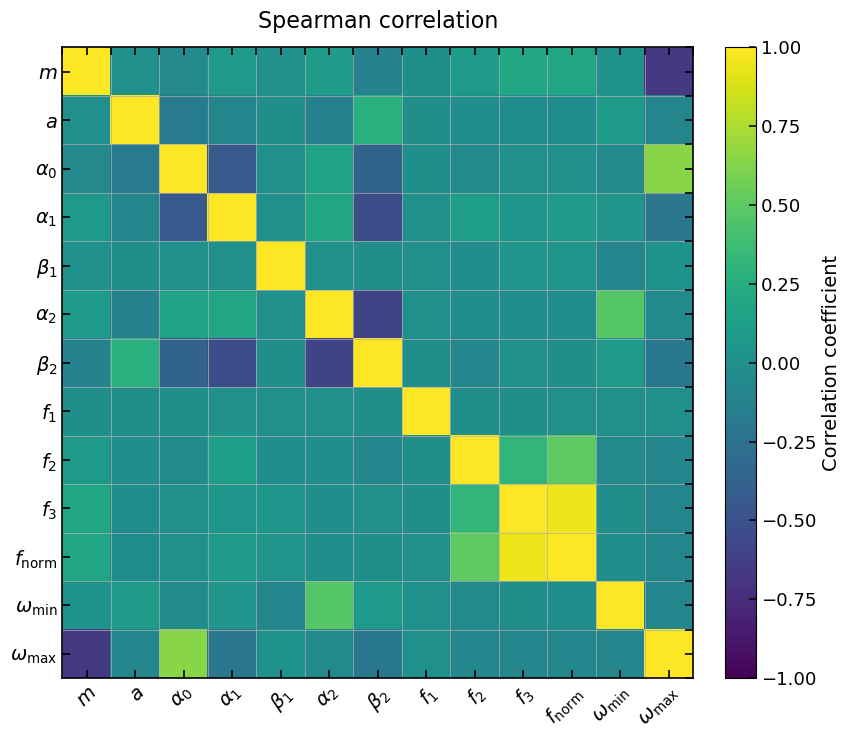

In [12]:

# Optional: make the same heat maps without numbers in the cells.
# This can be cleaner if the final figure is small in the manuscript.

fig, ax = plot_correlation_heatmap(
    pearson_corr,
    title="Pearson correlation",
    filename_stem="pearson_correlation_heatmap_no_annotations",
    annotate=False,
)
plt.show()

fig, ax = plot_correlation_heatmap(
    spearman_corr,
    title="Spearman correlation",
    filename_stem="spearman_correlation_heatmap_no_annotations",
    annotate=False,
)
plt.show()



## Optional: correlations by dataset

The cells below compute separate Pearson and Spearman heat maps for each dataframe. This is useful for checking whether the combined correlations are consistent across independent sweeps.


Saved correlation_heatmaps_013_014/dataframe000013_pearson_correlation_heatmap.png
Saved correlation_heatmaps_013_014/dataframe000013_pearson_correlation_heatmap.pdf


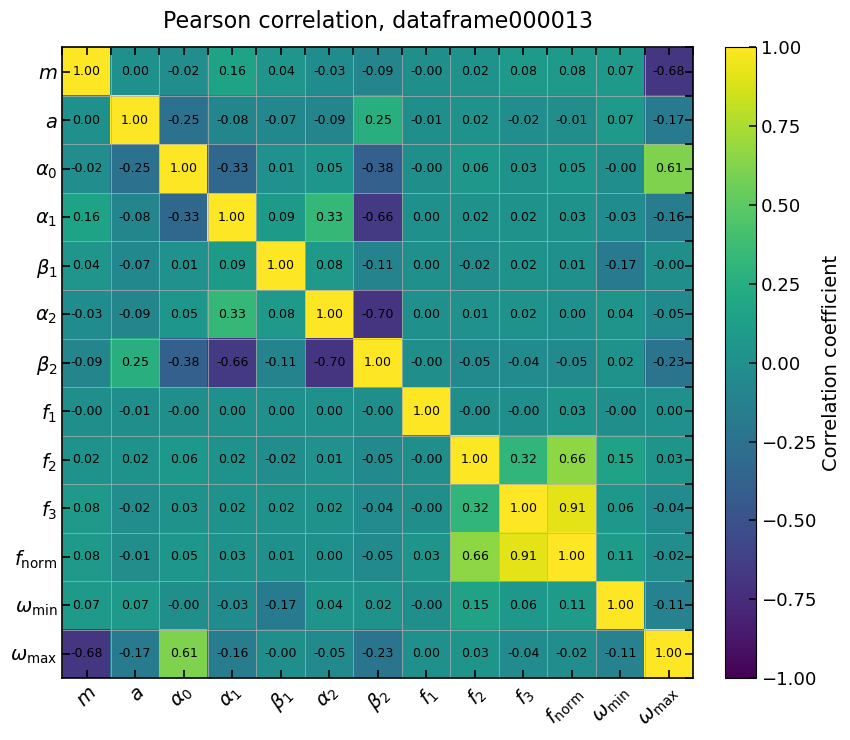

Saved correlation_heatmaps_013_014/dataframe000013_spearman_correlation_heatmap.png
Saved correlation_heatmaps_013_014/dataframe000013_spearman_correlation_heatmap.pdf


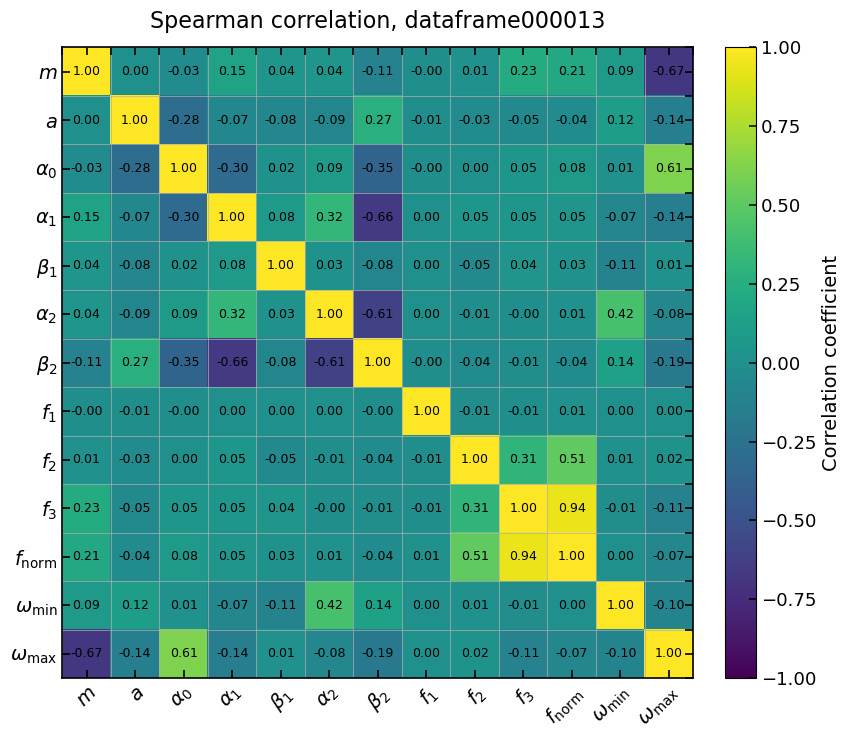

Saved correlation_heatmaps_013_014/dataframe000014_pearson_correlation_heatmap.png
Saved correlation_heatmaps_013_014/dataframe000014_pearson_correlation_heatmap.pdf


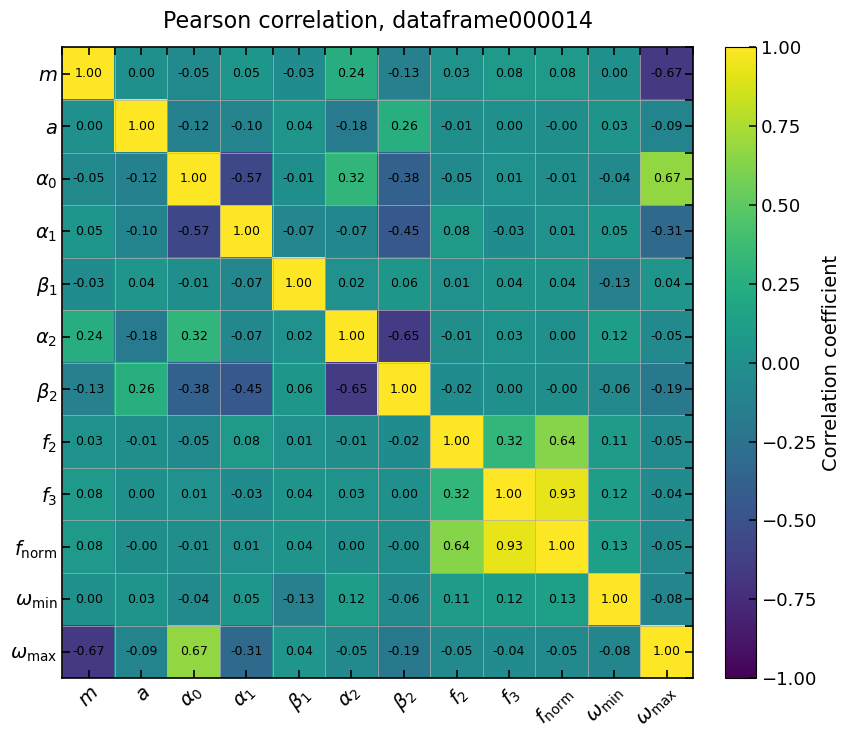

Saved correlation_heatmaps_013_014/dataframe000014_spearman_correlation_heatmap.png
Saved correlation_heatmaps_013_014/dataframe000014_spearman_correlation_heatmap.pdf


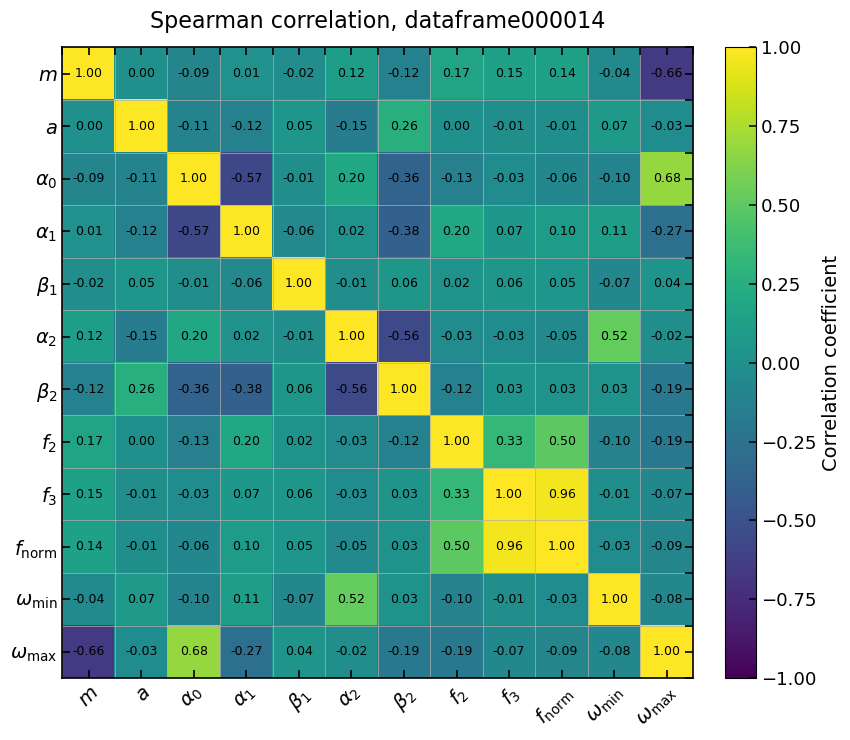

In [13]:

for dataset_name, group in df.groupby("dataset"):
    group_corr_df = group[corr_df.columns].copy()
    for c in group_corr_df.columns:
        if pd.api.types.is_bool_dtype(group_corr_df[c]):
            group_corr_df[c] = group_corr_df[c].astype(int)
        group_corr_df[c] = pd.to_numeric(group_corr_df[c], errors="coerce")

    group_corr_df = group_corr_df[
        [c for c in group_corr_df.columns if group_corr_df[c].dropna().nunique() > 1]
    ]

    p_corr = group_corr_df.corr(method="pearson")
    s_corr = group_corr_df.corr(method="spearman")

    p_corr.to_csv(OUTPUT_DIR / f"{dataset_name}_pearson_correlation_matrix.csv")
    s_corr.to_csv(OUTPUT_DIR / f"{dataset_name}_spearman_correlation_matrix.csv")

    fig, ax = plot_correlation_heatmap(
        p_corr,
        title=f"Pearson correlation, {dataset_name}",
        filename_stem=f"{dataset_name}_pearson_correlation_heatmap",
        annotate=True,
    )
    plt.show()

    fig, ax = plot_correlation_heatmap(
        s_corr,
        title=f"Spearman correlation, {dataset_name}",
        filename_stem=f"{dataset_name}_spearman_correlation_heatmap",
        annotate=True,
    )
    plt.show()



## Notes for interpretation

- **Pearson correlation** measures linear relationships.
- **Spearman correlation** measures monotonic relationships and is less sensitive to nonlinear scaling and outliers.
- Large positive or negative values indicate strong coupling between quantities, but they do not by themselves imply causation.
- In this MOGA-Phonons context, correlations involving $f_1$, $f_2$, $f_3$, $f_{\mathrm{norm}}$, and $N_-$ are useful diagnostics of how the force-constant parameters and lattice descriptors influence stability and optimization performance.
